In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../beam_search_summary_test.csv")
df.columns

Index(['dataset', 'beam_width', 'k', 'avg_edges_1.0', 'train_relevant_1.0',
       'train_seen_1.0', 'train_expanded_1.0', 'avg_edges_0.995',
       'train_relevant_0.995', 'train_seen_0.995',
       ...
       'train_seen_0.815', 'train_expanded_0.815', 'avg_edges_0.81',
       'train_relevant_0.81', 'train_seen_0.81', 'train_expanded_0.81',
       'avg_edges_0.805', 'train_relevant_0.805', 'train_seen_0.805',
       'train_expanded_0.805'],
      dtype='str', length=163)

In [3]:
import pandas as pd

# Melt all sparsity-suffixed columns
id_vars = ['dataset', 'beam_width', 'k']

df_long = pd.wide_to_long(
    df,
    stubnames=['avg_edges', 'train_relevant', 'train_seen', 'train_expanded'],
    i=id_vars,
    j='coverage',
    sep='_',
    suffix=r'[\d.]+'
).reset_index()

df_long['coverage'] = df_long['coverage'].astype(float)
df_long

,dataset,beam_width,k,coverage,avg_edges,train_relevant,train_seen,train_expanded
0,fashion_mnist,1,1,1.000,13.551550,0.5256,182.2118,10.3772
1,fashion_mnist,1,1,0.995,5.605650,0.2714,106.1895,11.9430
2,fashion_mnist,1,1,0.990,4.864417,0.1887,96.0519,11.8467
3,fashion_mnist,1,1,0.985,4.450817,0.1745,83.4374,11.3810
4,fashion_mnist,1,1,0.980,4.167867,0.1463,76.8211,11.1718
...,...,...,...,...,...,...,...,...
4795,mnist,256,100,0.825,2.835500,50.9962,600.5930,322.6074
4796,mnist,256,100,0.820,2.797150,49.1927,593.3778,322.5427
4797,mnist,256,100,0.815,2.759533,47.9524,587.7939,323.2436
4798,mnist,256,100,0.810,2.724333,46.9748,582.5775,324.5453


In [4]:
df_long['recall'] = df_long['train_relevant'] / df_long['k']
baseline = df_long[df_long['coverage'] == 1.0].copy()
novel    = df_long[df_long['coverage'] <  1.0].copy()
baseline_ref = baseline[['dataset', 'beam_width', 'k', 'recall', 'train_seen', 'avg_edges']] \
    .rename(columns={'recall': 'baseline_recall', 'train_seen': 'baseline_seen', 'avg_edges': 'baseline_avg_edges'})

novel = novel.merge(baseline_ref, on=['dataset', 'beam_width', 'k'])
novel['recall_ratio'] = novel['recall'] / novel['baseline_recall']
novel['recall_diff'] = novel['recall'] - novel['baseline_recall']
novel['compute_ratio'] = novel['train_seen'] / novel['baseline_seen']
novel['degree_ratio'] = novel['avg_edges'] / novel['baseline_avg_edges']

In [ ]:
# 1. Pick the single best baseline: coverage=1.0, highest beam_width
best_baseline = (
    df_long[df_long['coverage'] == 1.0]
    .sort_values('beam_width', ascending=False)
    .groupby(['dataset', 'k'], as_index=False)
    .first()
)[['dataset', 'k', 'recall', 'train_seen', 'avg_edges']] \
 .rename(columns={
     'recall':     'baseline_recall',
     'train_seen': 'baseline_seen',
     'avg_edges':  'baseline_avg_edges'
 })

# 2. Merge on (dataset, k) only — no beam_width
novel = df_long[df_long['coverage'] < 1.0].copy()
novel = novel.merge(best_baseline, on=['dataset', 'k'])

novel['recall_ratio']  = novel['recall']      / novel['baseline_recall']
novel['recall_diff']   = novel['recall']      - novel['baseline_recall']
novel['compute_ratio'] = novel['train_seen']  / novel['baseline_seen']
novel['degree_ratio']  = novel['avg_edges']   / novel['baseline_avg_edges']

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np

def pareto_frontier(df, x_col, y_col):
    pts = df[[x_col, y_col]].values
    is_pareto = np.ones(len(pts), dtype=bool)
    for i in range(len(pts)):
        if not is_pareto[i]:
            continue
        dominated = (pts[:, 0] <= pts[i, 0]) & (pts[:, 1] >= pts[i, 1])
        dominated[i] = False
        if dominated.any():
            is_pareto[i] = False
    return df[is_pareto].sort_values(x_col)

datasets = sorted(novel['dataset'].unique())
ks       = sorted(novel['k'].unique())

fig = make_subplots(
    rows=len(datasets), cols=len(ks),
    subplot_titles=[f'{d}  |  Recall@{k}' for d in datasets for k in ks],
    horizontal_spacing=0.06,
    vertical_spacing=0.12,
)

for row_idx, dataset in enumerate(datasets, start=1):
    baseline_bw = int(
        df_long[(df_long['dataset'] == dataset) & (df_long['coverage'] == 1.0)]['beam_width'].max()
    )

    for col_idx, k in enumerate(ks, start=1):
        sub = novel[(novel['dataset'] == dataset) & (novel['k'] == k)].copy()
        if sub.empty:
            continue

        if 'recall_diff' not in sub.columns:
            sub['recall_diff'] = sub['recall'] - sub['baseline_recall']

        ref             = sub.iloc[0]
        baseline_recall = ref['baseline_recall']
        baseline_seen   = ref['baseline_seen']

        full_cov = df_long[
            (df_long['dataset'] == dataset) & (df_long['k'] == k) & (df_long['coverage'] == 1.0)
        ].copy().sort_values('beam_width')

        show_legend = (row_idx == 1 and col_idx == 1)

        # ── Full-coverage reference curve ────────────────────────────────────
        fig.add_trace(go.Scatter(
            x=full_cov['train_seen'],
            y=full_cov['recall'],
            mode='lines+markers',
            name='Full coverage',
            legendgroup='full_cov',
            showlegend=show_legend,
            line=dict(color='crimson', width=2, dash='dot'),
            marker=dict(symbol='diamond', size=9, color='crimson',
                        line=dict(color='black', width=1)),
            customdata=full_cov['beam_width'].values[:, None],
            hovertemplate=(
                '<b>Full Coverage</b><br>'
                'beam_width: %{customdata[0]:.0f}<br>'
                'recall: %{y:.4f}<br>'
                'train_seen: %{x:.0f}'
                '<extra></extra>'
            ),
        ), row=row_idx, col=col_idx)

        # ── Novel scatter (all grey) ─────────────────────────────────────────
        fig.add_trace(go.Scatter(
            x=sub['train_seen'],
            y=sub['recall'],
            mode='markers',
            name='Novel',
            legendgroup='novel',
            showlegend=show_legend,
            marker=dict(color='#aaaaaa', size=6, opacity=0.4),
            customdata=np.column_stack([
                sub['beam_width'].values,
                sub['coverage'].values,
                sub['recall_diff'].values,
                sub['avg_edges'].values,
            ]),
            hovertemplate=(
                '<b>Novel</b><br>'
                'beam_width: %{customdata[0]:.0f}<br>'
                'coverage: %{customdata[1]:.3f}<br>'
                'recall: %{y:.4f}<br>'
                'recall_diff: %{customdata[2]:+.4f}<br>'
                'train_seen: %{x:.0f}<br>'
                'avg_edges: %{customdata[3]:.2f}'
                '<extra></extra>'
            ),
        ), row=row_idx, col=col_idx)

        # ── Pareto frontier ──────────────────────────────────────────────────
        frontier = pareto_frontier(
            sub[['train_seen', 'recall', 'beam_width', 'coverage', 'recall_diff']].dropna(),
            'train_seen', 'recall'
        )
        fig.add_trace(go.Scatter(
            x=frontier['train_seen'],
            y=frontier['recall'],
            mode='lines+markers',
            name='Pareto frontier',
            legendgroup='pareto',
            showlegend=show_legend,
            line=dict(color='black', width=2, dash='dash'),
            marker=dict(color='black', size=10, symbol='circle',
                        line=dict(color='white', width=1.5)),
            customdata=np.column_stack([
                frontier['beam_width'].values,
                frontier['coverage'].values,
                frontier['recall_diff'].values,
            ]),
            hovertemplate=(
                '<b>Pareto Point</b><br>'
                'beam_width: %{customdata[0]:.0f}<br>'
                'coverage: %{customdata[1]:.3f}<br>'
                'recall: %{y:.4f}<br>'
                'recall_diff: %{customdata[2]:+.4f}<br>'
                'train_seen: %{x:.0f}<br>'
                'avg_edges: %{customdata[3]:.2f}'
                '<extra></extra>'
            ),
        ), row=row_idx, col=col_idx)

        fig.add_hline(y=baseline_recall, line=dict(color='crimson', width=1, dash='dot'), row=row_idx, col=col_idx)
        fig.add_vline(x=baseline_seen,   line=dict(color='crimson', width=1, dash='dot'), row=row_idx, col=col_idx)

fig.update_layout(
    title=dict(text=f'<b>Recall vs Distance Computations</b>   <span style="font-size:12px;color:gray">Baseline: bw={baseline_bw}, coverage=1.0</span>'),
    height=400 * len(datasets),
    hovermode='closest',
    legend=dict(bgcolor='rgba(255,255,255,0.85)', bordercolor='lightgray', borderwidth=1),
)
fig.update_xaxes(title_text='Distance Computations (train_seen)')
fig.update_yaxes(title_text='Recall')

fig.write_html('/Users/pratyushavi/Developer/WebDev/scoogleystinkbomb/notes/navigable-graphs/recall_plots.html')
fig.show()


In [17]:
def top_k_bw_coverage(df_novel, top_k=5, group_by=('dataset', 'k'), score_col='recall'):
    """
    Return the top-k (beam_width, coverage) combinations per group, ranked by score_col descending.
    """
    return (
        df_novel
        .sort_values(score_col, ascending=False)
        .groupby(list(group_by), sort=False)
        .head(top_k)
        [list(group_by) + ['beam_width', 'coverage', score_col]]
        .reset_index(drop=True)
    )

def pareto_bw_coverage(df_novel, xcol='train_seen', score_col='recall', group_by=('dataset', 'k')):
    """
    Return Pareto-optimal (beam_width, coverage) combinations per group.
    A row is Pareto-optimal if no other row in the group has both higher score_col and lower xcol.
    """
    pieces = [
        pareto_frontier(g, xcol, score_col)
        for _, g in df_novel.groupby(list(group_by), sort=False)
    ]
    result = pd.concat(pieces, ignore_index=True)
    return result[list(group_by) + ['beam_width', 'coverage', score_col, xcol]]

def plot_top_k_settings(df_novel, df_baseline, score_col='recall', save=False):
    """
    For each dataset: one figure with rows=recall@k values, cols=[distance comps, avg out-edges].
    Pareto-optimal novel (bw, coverage) combos shown with distinct marker+color; baseline as a dashed line.
    """
    datasets = sorted(df_novel['dataset'].unique())
    k_values = sorted(df_novel['k'].unique())
    n_k      = len(k_values)

    for dataset in datasets:
        nov_ds  = df_novel[df_novel['dataset'] == dataset]
        base_ds = df_baseline[df_baseline['dataset'] == dataset]

        # Union of Pareto-optimal combos across all k values for this dataset
        pareto_per_k = pareto_bw_coverage(nov_ds, group_by=('k',), score_col=score_col)
        unique_combos = (
            pareto_per_k[['beam_width', 'coverage']]
            .drop_duplicates()
            .sort_values(['beam_width', 'coverage'])
            .reset_index(drop=True)
        )

        fig, axes = plt.subplots(n_k, 2, figsize=(14, 5 * n_k), squeeze=False)
        fig.suptitle(f'Dataset: {dataset}', fontsize=14, fontweight='bold')

        for row_idx, k in enumerate(k_values):
            nov_k  = nov_ds[nov_ds['k'] == k]
            base_k = base_ds[base_ds['k'] == k]

            ax_dist  = axes[row_idx, 0]
            ax_edges = axes[row_idx, 1]

            for ax, xcol, xlabel in [
                (ax_dist,  'train_seen', 'Distance Computations'),
                (ax_edges, 'avg_edges',  'Avg. Out-Edges'),
            ]:
                # Baseline: line connecting bw values at coverage=1.0
                base_sorted = base_k.sort_values(xcol)
                ax.plot(
                    base_sorted[xcol], base_sorted['recall'],
                    color='black', linestyle='--', linewidth=1.5,
                    marker='x', markersize=7, zorder=3, label='Baseline (cov=1.0, bw varies)',
                )

                # Pareto-optimal combos
                for i, (_, combo) in enumerate(unique_combos.iterrows()):
                    bw, cov = combo['beam_width'], combo['coverage']
                    row = nov_k[(nov_k['beam_width'] == bw) & (nov_k['coverage'] == cov)]
                    if row.empty:
                        continue
                    ax.scatter(
                        row[xcol].values[0], row['recall'].values[0],
                        marker=_MARKERS[i % len(_MARKERS)],
                        color=_COLORS[i % len(_COLORS)],
                        s=90, zorder=5, label=f'bw={int(bw)}, cov={cov:.2f}',
                    )

                ax.set_xlabel(xlabel, fontsize=10)
                ax.set_ylabel(f'Recall@{k}', fontsize=10)
                ax.set_title(f'Recall@{k} vs {xlabel}', fontsize=11)
                ax.legend(
                    loc='upper center', bbox_to_anchor=(0.5, -0.22),
                    ncol=3, fontsize=8, frameon=True,
                )

        plt.tight_layout()
        if save:
            fig.savefig(f'{dataset}_pareto.png', bbox_inches='tight', dpi=150)
        plt.show()

In [18]:
pareto_bw_coverage(novel)

,dataset,k,beam_width,coverage,recall,train_seen
0,fashion_mnist,1,1,0.805,0.003100,20.9474
1,fashion_mnist,1,1,0.810,0.003200,21.7014
2,fashion_mnist,1,1,0.815,0.005100,25.8986
3,fashion_mnist,1,1,0.825,0.007500,29.1721
4,fashion_mnist,1,1,0.835,0.007800,29.9735
...,...,...,...,...,...,...
1288,mnist,100,100,0.995,0.962451,624.6882
1289,mnist,100,128,0.995,0.977509,741.1211
1290,mnist,100,256,0.985,0.981934,987.0352
1291,mnist,100,256,0.990,0.988817,1066.7604


In [19]:
# top_k = top_k_bw_coverage(novel, top_k=10)
top_k = pareto_bw_coverage(novel)

# Set of (bw, coverage) combos per (dataset, k)
sets = (
    top_k.groupby(['dataset', 'k'])
    .apply(lambda g: set(zip(g['beam_width'], g['coverage'])))
    .rename('combos')
    .reset_index()
)

# Intersection across k values, per dataset
intersection = (
    sets.groupby('dataset')['combos']
    .apply(lambda s: set.intersection(*s))
    .reset_index()
    .rename(columns={'combos': 'common_combos'})
)

sets_by_k = sets.set_index(['dataset', 'k'])['combos']

# For each (dataset, k), which combos are NOT in the other k's intersection?
sets['unique_to_k'] = sets.apply(
    lambda r: r['combos'] - intersection.set_index('dataset').loc[r['dataset'], 'common_combos'],
    axis=1
)
sets[['dataset', 'k', 'unique_to_k']]

,dataset,k,unique_to_k
0,coco_i2i,1,"{(4, 0.99), (16, 0.995), (64, 0.995), (1, 0.95..."
1,coco_i2i,10,"{(4, 0.875), (4, 0.92), (2, 0.9), (8, 0.955), ..."
2,coco_i2i,100,"{(8, 0.885), (16, 0.96), (4, 0.875), (64, 0.88..."
3,fashion_mnist,1,"{(1, 0.93), (4, 0.955), (8, 0.955), (16, 0.995..."
4,fashion_mnist,10,"{(16, 0.96), (4, 0.875), (1, 0.93), (4, 0.955)..."
5,fashion_mnist,100,"{(8, 0.885), (16, 0.835), (16, 0.96), (64, 0.8..."
6,glove25,1,"{(2, 0.98), (4, 0.99), (16, 0.995), (2, 0.935)..."
7,glove25,10,"{(4, 0.875), (4, 0.955), (1, 0.885), (4, 0.865..."
8,glove25,100,"{(8, 0.885), (16, 0.96), (4, 0.875), (8, 0.875..."
9,mnist,1,"{(1, 0.93), (2, 0.98), (4, 0.99), (16, 0.995),..."


/var/folders/4g/9lqkf_390k1bb7dv53djxdy00000gn/T/ipykernel_23173/3672924101.py:91: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


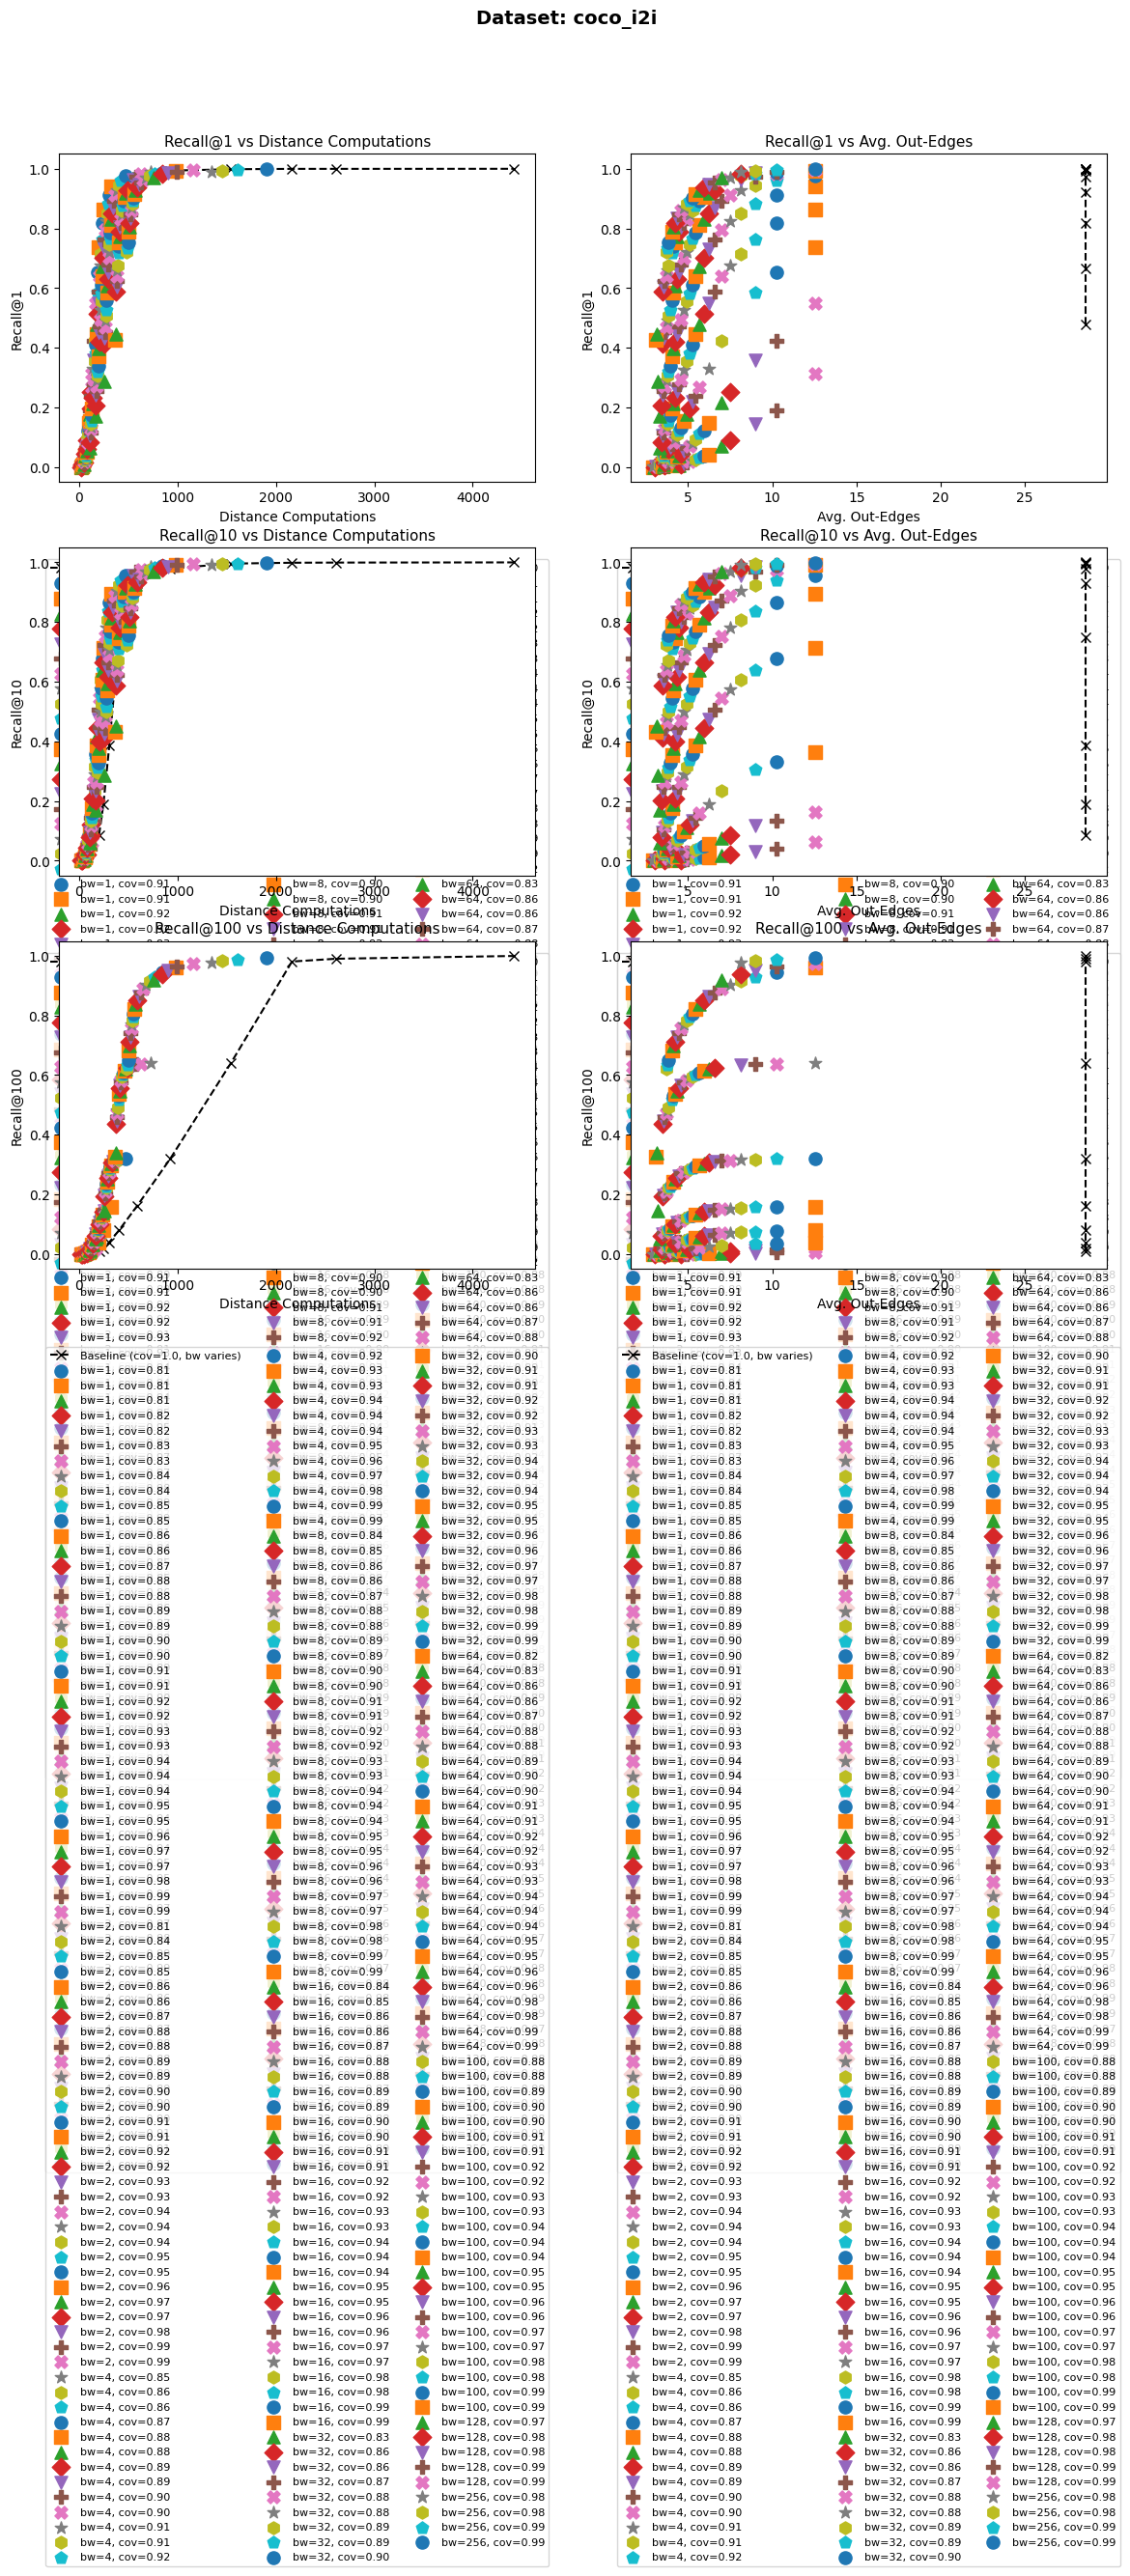

/var/folders/4g/9lqkf_390k1bb7dv53djxdy00000gn/T/ipykernel_23173/3672924101.py:91: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


KeyboardInterrupt: 

In [20]:
_MARKERS = ['o', 's', '^', 'D', 'v', 'P', 'X', '*', 'h', 'p']
_COLORS  = plt.cm.tab10.colors
plot_top_k_settings(novel, baseline)
# save to disk:
# plot_top_k_settings(novel, baseline, save=True)